<b><font size="6" color="#f35b1f">Week 4: Cross-Validation — Evaluating a Model Honestly</font></b><br>

Up to week 3 the pipeline judged every model on **one** train/test split. This notebook shows why that number can't be trusted on its own, and builds the evaluation design the pipeline uses: a **locked test set**, and **stratified k-fold cross-validation** of the *whole* pipeline (preprocessing + model) on everything else.

Along the way it covers the full toolbox - holdout, train/validation/test, k-fold and its stratified and repeated variants, leave-one-out, group- and time-aware splitters - and three things beyond it: how reliable each design actually is, how large preprocessing leakage can get, and how to compare two models on the same folds without fooling yourself.

**See it here first, then add it to the pipeline.** Cross-validation is wrapped **around** the pipeline from `02_preprocessing.ipynb`. Every function used here is written out and run in this notebook - **character for character the same code** as in the pipeline, called with the same arguments `main.py` passes. The new ones (`split_dev_test()`, and the CV functions for `src/evaluate.py`) are introduced where they're taught; Section 6 collects what to copy. What you see here is what your `python main.py` will do.

Only `config.yaml` and the data file are read from the pipeline folder (`PIPELINE_DIR`).

<div class="alert alert-block alert-info">

## Table of Contents<a class="anchor" id="toc"></a>
### [<font color='#f35b1f'>1 - Setup: Load Your Pipeline</font>](#setup)
### [<font color='#f35b1f'>2 - Holdout: Training, Validation and Test</font>](#holdout)
* [2.1 - Locking the test set](#lock) · [2.2 - Training and validation](#train-val) · [2.3 - Why a single split lies](#single-split)
### [<font color='#f35b1f'>3 - Cross-Validation Techniques</font>](#cv)
* [3.1 - K-Fold and Stratified K-Fold](#kfold) · [3.2 - Cross-validating the whole pipeline](#cv-pipeline) · [3.3 - Group-aware and time-aware splitting](#group-time) · [3.4 - Which design is most reliable?](#reliability)
### [<font color='#f35b1f'>4 - The Leakage Trap: Preprocessing Belongs Inside the Folds</font>](#leakage)
### [<font color='#f35b1f'>5 - Adding Cross-Validation to Your Pipeline</font>](#pipeline)
### [<font color='#f35b1f'> Key Takeaways; README;  Challenge</font>](#workflow)
</div>

## <font color='#f35b1f'>1. Setup: Load Your Pipeline</font> <a class="anchor" id="setup"></a>
[Back to TOC](#toc)

In [1]:
# Install the packages this notebook needs (skip if your environment already has them)
#%pip install -q pandas numpy "scikit-learn>=1.9" PyYAML category-encoders matplotlib

In [2]:
import copy
import sys
import time
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yaml
from pprint import pprint
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, TargetEncoder, StandardScaler, MinMaxScaler, RobustScaler,
)
from category_encoders import CountEncoder
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, RepeatedStratifiedKFold, LeaveOneOut,
    GroupKFold, TimeSeriesSplit, cross_validate, cross_val_score,
)

pd.set_option("display.width", 160)
BLUE, ORANGE, GRAY, GREEN, LIGHT = "#1B6FA8", "#f35b1f", "#6B7280", "#6CD69A", "#9CC3E0"
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["font.size"] = 10.5

**The pipeline so far** - exactly the functions built and explained in `02_preprocessing.ipynb` (cleaning, features, `build_preprocessor()`, `build_model()`). Nothing new here: run it and move on.

In [3]:
# ---- src/data.py -- identical to the pipeline ----
def load_data(path: str) -> pd.DataFrame:
    """Load the raw dataset from a CSV file."""
    return pd.read_csv(path)

In [4]:
# ---- src/preprocessing.py -- identical to the pipeline ----
def flag_invalid_values(df: pd.DataFrame, rules: dict) -> pd.DataFrame:
    """
    Applies a dict of {column: {"min": ..., "max": ...}} domain rules (either bound is
    optional) and converts violations to NaN **in place** on `df`. An "impossible but
    not missing" value (an age of -3, a COMPAS decile score of 15) counts as missing
    once this runs -- `.isna()` alone would never have caught it.

    Returns a small report: how many violations were found per column.
    """
    report_rows = []
    for column, bounds in rules.items():
        if column not in df.columns:
            continue
        numeric = pd.to_numeric(df[column], errors="coerce")
        lower_ok = numeric >= bounds["min"] if "min" in bounds else pd.Series(True, index=numeric.index)
        upper_ok = numeric <= bounds["max"] if "max" in bounds else pd.Series(True, index=numeric.index)
        violations = numeric.notna() & ~(lower_ok & upper_ok)
        report_rows.append({"column": column, "rule": bounds, "violations": int(violations.sum())})
        df.loc[violations, column] = np.nan
    return pd.DataFrame(report_rows)


def _canonicalize_categories(df: pd.DataFrame, columns_and_maps: dict, placeholder_tokens: set) -> pd.DataFrame:
    out = df.copy()
    for col, mapping in columns_and_maps.items():
        if col not in out.columns:
            continue
        cleaned = out[col].astype(str).str.strip()
        lowered = cleaned.str.lower()
        out[col] = lowered.map(mapping).fillna(cleaned)
        out.loc[out[col].astype(str).str.strip().isin(placeholder_tokens), col] = np.nan
    return out


def clean_dataset(df: pd.DataFrame, diagnostics_config: dict) -> pd.DataFrame:
    """
    Applies the week 3 diagnosis: category cleanup, domain-rule/placeholder -> NaN
    conversion, and redundant-column removal. Target-agnostic -- safe to call on
    label-free inference data, since none of this depends on a target column.

    Row-preserving (week 4): every input row comes out, in the same order. Removing
    duplicate rows is a *training-only* decision and lives in `drop_duplicate_rows()` --
    at prediction time every row needs a prediction (a Kaggle submission needs one per id).
    """
    out = df.copy()
    placeholder_tokens = set(diagnostics_config.get("placeholder_tokens", []))

    # numeric columns that load as text purely because of a placeholder token
    for col in diagnostics_config.get("numeric_text_columns", []):
        if col in out.columns:
            out[col] = pd.to_numeric(out[col].replace(list(placeholder_tokens), np.nan), errors="coerce")

    flag_invalid_values(out, diagnostics_config.get("validity_rules", {}))

    out = _canonicalize_categories(out, diagnostics_config.get("canonical_categories", {}), placeholder_tokens)

    columns_to_drop = [c for c in diagnostics_config.get("redundant_columns", []) if c in out.columns]
    out = out.drop(columns=columns_to_drop)

    return out


def drop_duplicate_rows(df: pd.DataFrame, id_column: str = None) -> pd.DataFrame:
    """
    TRAINING DATA ONLY (week 4). Drops exact duplicate rows and repeated ids (keeping
    the first), so the same person can't be counted twice -- or land in both the
    development and the locked test set. Must run *before* `split_dev_test()`.

    Never call this on data you're predicting for: every row there needs a prediction.
    """
    out = df.drop_duplicates()
    if id_column and id_column in out.columns:
        out = out.drop_duplicates(subset=id_column, keep="first")
    return out


def add_missingness_indicators(df: pd.DataFrame, mnar_indicator_sources: list) -> pd.DataFrame:
    """Adds a `<col>_was_missing` flag for each MNAR-diagnosed column, before that
    column gets imputed -- so a model can still see the pattern even though the fill
    value itself (median/mode) can't carry it. Target-agnostic."""
    out = df.copy()
    for col in mnar_indicator_sources:
        if col in out.columns:
            out[f"{col}_was_missing"] = out[col].isna().astype(int)
    return out


def split_features_target(df: pd.DataFrame, data_config: dict, mnar_indicator_sources: list):
    """
    Returns (X, y, extras). `y` is `None` and `extras` has no target column when called
    on label-free inference data -- nothing downstream requires the target to be present.
    """
    target = data_config["target"]
    sensitive_attr = data_config["sensitive_attr"]
    drop_columns = data_config.get("drop_columns", [])

    df = add_missingness_indicators(df, mnar_indicator_sources)
    y = df[target] if target in df.columns else None

    extras_cols = [c for c in [sensitive_attr, "score_text"] if c in df.columns]
    extras = df[extras_cols].copy() if extras_cols else None

    always_drop = set(drop_columns) | {target, sensitive_attr}
    feature_cols = [c for c in df.columns if c not in always_drop]
    X = df[feature_cols]
    return X, y, extras


_SCALERS = {"none": "passthrough", "standard": StandardScaler, "minmax": MinMaxScaler, "robust": RobustScaler}


_ENCODERS = {
    "onehot": lambda seed: OneHotEncoder(handle_unknown="ignore", sparse_output=False),
    "ordinal": lambda seed: OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
    "count": lambda seed: CountEncoder(handle_unknown=0, handle_missing=0),
    "target": lambda seed: TargetEncoder(target_type="binary", cv=StratifiedKFold(5, shuffle=True, random_state=seed)),
}


def build_preprocessor(preprocessing_config: dict) -> ColumnTransformer:
    """
    Factory: builds a leak-safe ColumnTransformer for the chosen encoder/scaler pair --
    read from `config.yaml`'s `preprocessing` section (chosen there, not hardcoded
    here). Every encoder tolerates unseen
    categories at transform time. Nothing is fit here: fitting happens later, on the
    training part of each CV fold only, because this object is placed *inside* the
    model's sklearn Pipeline (see main.py).
    """
    encoder_name = preprocessing_config["encoder"]
    scaler_name = preprocessing_config["scaler"]
    numeric_features = preprocessing_config["numeric_features"]
    categorical_features = preprocessing_config["categorical_features"]
    mnar_indicator_sources = preprocessing_config.get("mnar_indicator_sources", [])
    imputation = preprocessing_config.get("imputation", {})

    scaler_factory = _SCALERS[scaler_name]
    scaler = scaler_factory() if callable(scaler_factory) else scaler_factory
    encoder = _ENCODERS[encoder_name](preprocessing_config.get("random_state"))

    numeric_pipeline = Pipeline([
        ("impute", SimpleImputer(strategy=imputation.get("numeric_strategy", "median"))),
        ("scale", scaler),
    ])
    categorical_pipeline = Pipeline([
        ("impute", SimpleImputer(strategy=imputation.get("categorical_strategy", "most_frequent"))),
        ("encode", encoder),
    ])

    indicator_cols = [f"{c}_was_missing" for c in mnar_indicator_sources]

    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
        ("indicators", "passthrough", indicator_cols),
    ])

In [5]:
# ---- src/model.py -- identical to the pipeline ----
_MODELS = {
    # always predicts the most frequent class -- the floor every real model must beat
    "dummy": DummyClassifier,
    "logistic_regression": LogisticRegression,
    "decision_tree": DecisionTreeClassifier,
    # week 4: an ensemble of decision trees, each trained on a bootstrap sample of the rows with a
    # random subset of features at every split; predictions are averaged. Untuned for now.
    "random_forest": RandomForestClassifier,
}


def build_model(model_config: dict):
    model_type = model_config["type"]
    params = model_config.get("params") or {}

    if model_type not in _MODELS:
        raise ValueError(f"Unknown model type: {model_type}. Options: {list(_MODELS)}")

    return _MODELS[model_type](**params)

Config and data from the pipeline folder, then exactly the first steps of `main.py`. The `data`, `diagnostics` and `preprocessing` sections were shown and explained in `02_preprocessing.ipynb`; the sections new this week (`test_set`, `cv`) are shown where they're used.

In [12]:
PIPELINE_DIR = Path("C:\\Users\\rafae\\Documents\\GitHub\\ETAI-Pipeline\\")        # where config.yaml and the data live (your fork, or the reference)

with open(PIPELINE_DIR / "config.yaml") as f:
    config = yaml.safe_load(f)
SEED = config["test_set"]["random_state"]

df_raw = load_data(PIPELINE_DIR / config["data"]["path"])
df_clean = clean_dataset(df_raw, config["diagnostics"])                            # row-preserving
df_clean = drop_duplicate_rows(df_clean, config["diagnostics"].get("id_column"))    # training data only
X, y, extras = split_features_target(df_clean, config["data"], config["preprocessing"]["mnar_indicator_sources"])
print(X.shape, f"-- reoffended: {y.mean():.1%}")
print("Recipe from config.yaml:", {k: config["preprocessing"][k] for k in ["encoder", "scaler"]})
X.head(3)

(7214, 10) -- reoffended: 45.1%
Recipe from config.yaml: {'encoder': 'target', 'scaler': 'robust'}


,juv_other_count,priors_count,juv_misd_count,sex,age_cat,c_charge_degree,juv_fel_count,age,priors_count_was_missing,c_charge_degree_was_missing
0,1,0.0,0,Male,25 - 45,F,0.0,27.0,0,0
1,0,3.0,0,Male,Less than 25,M,0.0,23.0,0,0
2,0,2.0,0,Male,25 - 45,F,0.0,28.0,0,0


In [13]:
def make_pipeline(model_config, preprocessing_config=None):
    # Same as main.py: Pipeline([("prep", build_preprocessor(...)), ("model", build_model(...))])
    return Pipeline([
        ("prep", build_preprocessor(preprocessing_config or config["preprocessing"])),
        ("model", build_model(model_config)),
    ])


MODELS = {   # each value is what you'd write under `model:` in config.yaml
    "Dummy (majority)": {"type": "dummy", "params": {}},
    "Logistic regression": {"type": "logistic_regression", "params": {"max_iter": 2000}},
    "Decision tree": {"type": "decision_tree", "params": {"random_state": SEED}},
    "Random forest": {"type": "random_forest", "params": {"n_estimators": 300, "random_state": SEED, "n_jobs": -1}},
}
LR = MODELS["Logistic regression"]
COLORS = dict(zip(MODELS, [GRAY, BLUE, ORANGE, GREEN]))
make_pipeline(LR)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=

## <font color='#f35b1f'>2. Holdout: Training, Validation and Test</font> <a class="anchor" id="holdout"></a>
[Back to TOC](#toc)

Three jobs, three sets of rows:

| Set | Job | May influence decisions? |
|---|---|---|
| **training** | fit the preprocessing and the model | yes |
| **validation** | compare candidates (recipes, models, hyperparameters) | yes — that's its purpose |
| **test** | assess the final choice, **once** | **no, never** |

A score that guided a decision is no longer an unbiased estimate: you picked the option that looked best *on those rows*, partly because of luck. Only rows that never influenced a decision can tell you how the final pipeline does on new people.

<a class="anchor" id="lock"></a>
### 2.1 · Locking the test set

<div class="alert alert-block alert-info">
<a href='https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html'>sklearn.model_selection.train_test_split(*arrays, test_size=None, random_state=None, shuffle=True, stratify=None)</a>

**Definition:**  
Split arrays into random train and test subsets.

**Common Parameters:**  
- `test_size`: share of rows for the test part
- `random_state`: seed that makes the split reproducible
- `stratify`: labels whose class proportions both parts keep
</div>

New this week in `src/preprocessing.py`, replacing `split_train_test()`:

In [14]:
# ---- src/preprocessing.py -- identical to the pipeline ----
def split_dev_test(X, y, extras, test_size: float, random_state: int):
    """
    Sets the final test set aside (week 4 -- replaces week 2/3's `split_train_test`).

    Stratified split of X, y and the extras frame (race/score_text, kept for the fairness
    report) together, so all three stay row-aligned. Returns a *development* set and a
    *locked test set*:
      - development set: everything we're allowed to learn from and compare models on.
        Cross-validation (src/evaluate.py) splits it again into train/validation folds.
      - locked test set: never used to fit, tune, compare or choose anything. Its size and seed live in config.yaml's `test_set` section and are never changed after today.
    """
    X_dev, X_test, y_dev, y_test, extras_dev, extras_test = train_test_split(
        X, y, extras, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_dev, X_test, y_dev, y_test, extras_dev, extras_test

**What it receives:** `test_size` and `random_state` from the new `test_set` section — set once this week and never changed again:

```yaml
# ---- config.yaml (exactly as in the pipeline) ----
# Week 4: the FINAL TEST SET. Carved out once, stratified, and locked: never used to fit,
# tune, compare or choose anything. Used only for the final assessment.
# Do not change these two values after week 4 -- a new seed would silently give you a
# different (already partly "seen") test set.
test_set:
  size: 0.2
  random_state: 42
```

In [15]:
print('config["test_set"] =', config["test_set"])
X_dev, X_test, y_dev, y_test, extras_dev, extras_test = split_dev_test(
    X, y, extras, test_size=config["test_set"]["size"], random_state=config["test_set"]["random_state"]
)
print(f"Development set: {len(X_dev)} rows  |  Locked test set: {len(X_test)} rows -- not touched again in this notebook")

config["test_set"] = {'size': 0.2, 'random_state': 42}
Development set: 5771 rows  |  Locked test set: 1443 rows -- not touched again in this notebook


Exactly the call `main.py` makes. The **development set** is everything we may learn from and compare on. 

<a class="anchor" id="train-val"></a>
### 2.2 · Training and validation

The classic holdout carves a validation set out of the development set (here 25% of it — the same size as the test set):

In [16]:
X_tr, X_va, y_tr, y_va = train_test_split(X_dev, y_dev, test_size=0.25, random_state=SEED, stratify=y_dev)
lr = make_pipeline(LR).fit(X_tr, y_tr)      # everything fitted on training rows
print(f"train {len(X_tr)} / validation {len(X_va)} / test {len(X_test)} (locked)")
print(f"Training accuracy:   {accuracy_score(y_tr, lr.predict(X_tr)):.3f}")
print(f"Validation accuracy: {accuracy_score(y_va, lr.predict(X_va)):.3f}")

train 4328 / validation 1443 / test 1443 (locked)
Training accuracy:   0.678
Validation accuracy: 0.674


This is what the pipeline did up to week 3. It's cheap and simple, and it has two weaknesses: only 25% of the development rows are ever used for validation, and the number depends on *which* 25%.

<a class="anchor" id="single-split"></a>
### 2.3 · Why a single split lies

The same model on the same data, validated on one 75/25 split — 30 times, changing only the split's random seed:

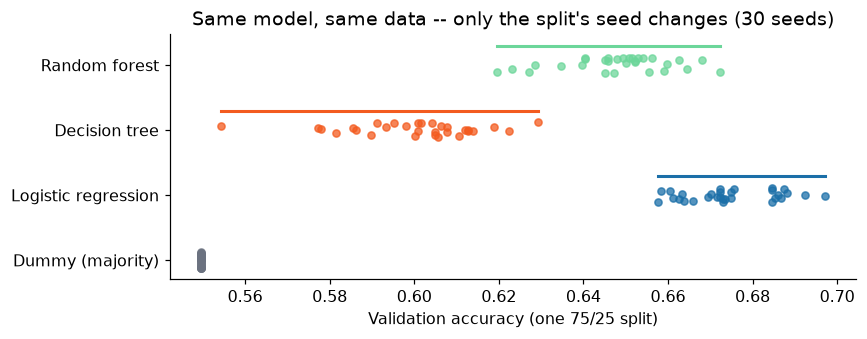

,min,max,mean,std,range
Dummy (majority),0.550,0.550,0.550,0.000,0.000
Logistic regression,0.658,0.697,0.675,0.011,0.040
Decision tree,0.554,0.629,0.600,0.015,0.075
Random forest,0.620,0.672,0.648,0.013,0.053


In [18]:
N_SEEDS = 30
holdout = {name: [] for name in MODELS}
for seed in range(N_SEEDS):
    Xa, Xb, ya, yb = train_test_split(X_dev, y_dev, test_size=0.25, random_state=seed, stratify=y_dev)
    for name, factory in MODELS.items():
        holdout[name].append(accuracy_score(yb, make_pipeline(factory).fit(Xa, ya).predict(Xb)))
holdout = pd.DataFrame(holdout)

fig, ax = plt.subplots(figsize=(8, 3.2))
rng = np.random.default_rng(0)
for i, (name, color) in enumerate(COLORS.items()):
    ax.scatter(holdout[name], i + rng.uniform(-0.12, 0.12, N_SEEDS), color=color, alpha=0.75, s=22)
    ax.plot([holdout[name].min(), holdout[name].max()], [i + 0.3] * 2, color=color, lw=2)
ax.set_yticks(range(len(MODELS)), list(MODELS)); ax.set_xlabel("Validation accuracy (one 75/25 split)")
ax.set_title(f"Same model, same data -- only the split's seed changes ({N_SEEDS} seeds)")
plt.tight_layout(); plt.show()

summary = holdout.agg(["min", "max", "mean", "std"]).T
summary["range"] = summary["max"] - summary["min"]
summary.round(3)

**A single holdout score is one draw from a distribution.** Its spread is several accuracy points — often more than the improvement you're trying to measure when you change a preprocessing step or a hyperparameter. We want two things: use **every** development row for validation, and report **how much the estimate moves**. That's cross-validation.

## <font color='#f35b1f'>3. Cross-Validation Techniques</font> <a class="anchor" id="cv"></a>
[Back to TOC](#toc)

<a class="anchor" id="kfold"></a>
### 3.1 · K-Fold and Stratified K-Fold

Split the development set into *k* folds. Train on *k*−1, validate on the remaining one; repeat *k* times so each fold validates exactly once. Report all *k* scores, their **mean** (the estimate) and **standard deviation** (how much it moves). The *k* models share most of their training rows, so the fold scores are not independent - keep that in mind in Section 5.

<div class="alert alert-block alert-info">
<a href='https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html'>sklearn.model_selection.KFold(n_splits=5, shuffle=False, random_state=None)</a>

**Definition:**  
K-Fold cross-validator: consecutive folds (or shuffled first, with `shuffle=True`).

**Common Parameters:**  
- `n_splits`: number of folds (≥ 2)
- `shuffle`: shuffle rows before cutting folds — without it, folds follow the file order
- `random_state`: seed for the shuffle
</div>

<div class="alert alert-block alert-info">
<a href='https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html'>sklearn.model_selection.StratifiedKFold(n_splits=5, shuffle=False, random_state=None)</a>

**Definition:**  
K-Fold variant that keeps each class's share the same in every fold.

**Common Parameters:**  
- `n_splits`: number of folds
- `shuffle`: shuffle within each class before splitting
- `random_state`: seed
</div>

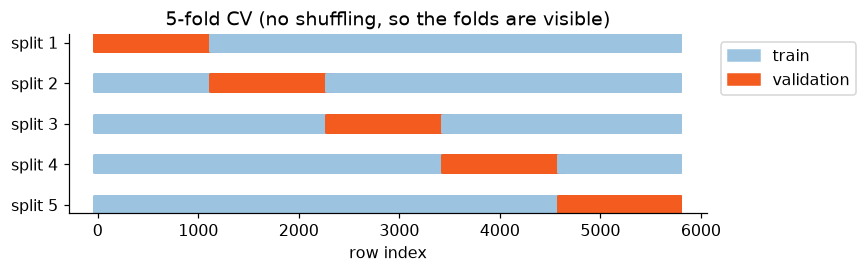

Share of reoffenders in the development set: 0.4507


,fold 1,fold 2,fold 3,fold 4,fold 5,max - min
splitter,,,,,,
KFold (shuffle),0.4623,0.4671,0.4541,0.4125,0.4575,0.0546
StratifiedKFold (shuffle),0.4511,0.4506,0.4506,0.4506,0.4506,0.0005


In [19]:
def plot_cv_indices(cv, X, y, ax, title, groups=None):
    used_everywhere = True
    for i, (tr, va) in enumerate(cv.split(X, y, groups)):
        colors = np.full(len(X), "#EEEEEE", dtype=object)
        colors[tr], colors[va] = LIGHT, ORANGE
        used_everywhere &= (len(tr) + len(va) == len(X))
        ax.scatter(range(len(X)), [i] * len(X), c=colors, marker="_", lw=12)
    ax.set_yticks(range(cv.get_n_splits(X, y, groups)), [f"split {i + 1}" for i in range(cv.get_n_splits(X, y, groups))])
    ax.invert_yaxis(); ax.set_xlabel("row index"); ax.set_title(title)
    handles = [Patch(color=LIGHT, label="train"), Patch(color=ORANGE, label="validation")]
    if not used_everywhere:
        handles.append(Patch(color="#EEEEEE", label="not used"))
    ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.01, 1))


fig, ax = plt.subplots(figsize=(8, 2.6))
plot_cv_indices(KFold(5), X_dev, y_dev, ax, "5-fold CV (no shuffling, so the folds are visible)")
plt.tight_layout(); plt.show()

rows = []
for name, cv in [("KFold (shuffle)", KFold(5, shuffle=True, random_state=SEED)),
                 ("StratifiedKFold (shuffle)", StratifiedKFold(5, shuffle=True, random_state=SEED))]:
    rates = [y_dev.iloc[va].mean() for _, va in cv.split(X_dev, y_dev)]
    rows.append({"splitter": name, **{f"fold {i + 1}": r for i, r in enumerate(rates)}, "max - min": max(rates) - min(rates)})
print(f"Share of reoffenders in the development set: {y_dev.mean():.4f}")
pd.DataFrame(rows).set_index("splitter").round(4)

Stratification makes every fold's class balance identical. On a ~45/55 target the difference is small; on a rare class (5% positives) plain k-fold can produce folds with almost no positives and wildly unstable scores. It costs nothing, so for classification we usually always stratify.

<a class="anchor" id="cv-pipeline"></a>
### 3.2 · Cross-validating the whole pipeline

<div class="alert alert-block alert-info">
<a href='https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html'>sklearn.model_selection.cross_validate(estimator, X, y, cv=None, scoring=None, return_train_score=False, ...)</a>

**Definition:**  
Fits a fresh clone of `estimator` on each training part and scores it on the matching validation part.

**Common Parameters:**  
- `estimator`: pass the whole `Pipeline`, so preprocessing is re-fitted in every fold
- `cv`: a splitter object (e.g. `StratifiedKFold`) or an int
- `scoring`: metric name(s), e.g. `'accuracy'`
- `return_train_score`: also score each fold's training rows — needed to see overfitting
</div>

The first two functions for **`src/evaluate.py`**: the splitter, built from `config.yaml`'s `cv` section, and CV of a whole pipeline returning train / validation / gap per fold:

In [20]:
# ---- src/evaluate.py -- identical to the pipeline ----
def cross_validate_pipeline(pipeline, X, y, cv, scoring: str = "accuracy", n_jobs: int = 1):
    """
    Fits a fresh copy of `pipeline` on each fold's training part and scores it on that
    fold's validation part. Because `pipeline` contains the preprocessing too, imputation
    medians, encoder statistics and scaler means are re-learned inside every fold -- the
    validation fold never influences its own preprocessing.

    Returns (fold_scores, y_oof):
      - fold_scores: one row per fold -- train score, validation score, and the gap between
        them (a large, consistent gap = overfitting).
      - y_oof: out-of-fold predictions. Every row gets a prediction from the one fold model
        that did NOT train on it, so all of them are "unseen" -- what the classification
        report and fairness check are computed on (more rows, and the locked test set stays
        untouched). Taken from the same fits as the scores, so nothing is fitted twice.
    """
    scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, return_train_score=True,
                            return_estimator=True, return_indices=True, n_jobs=n_jobs)
    fold_scores = pd.DataFrame({
        "fold": range(1, len(scores["test_score"]) + 1),
        "train": scores["train_score"],
        "validation": scores["test_score"],
    })
    fold_scores["gap"] = fold_scores["train"] - fold_scores["validation"]

    y_oof = np.empty(len(X), dtype=np.asarray(y).dtype)
    for model, val_idx in zip(scores["estimator"], scores["indices"]["test"]):
        y_oof[val_idx] = model.predict(X.iloc[val_idx])
    return fold_scores, y_oof

**What they receive:** the splitter is sklearn's `StratifiedKFold`, built straight from `n_splits`, `shuffle` and `random_state`; `scoring` and `n_jobs` are passed to `cross_validate_pipeline()`. The new `cv` section:

```yaml
# ---- config.yaml (exactly as in the pipeline) ----
# Week 4: how models are evaluated -- stratified k-fold cross-validation on the
# development set (everything except the locked test set). Same random_state = same folds on
# every run, for every model, so comparisons are like-for-like.
cv:
  n_splits: 5
  shuffle: true
  random_state: 42
  scoring: "accuracy"   # one metric for now, so numbers compare directly with weeks 2-3
  n_jobs: 1             # folds fitted in parallel; -1 = all cores (only pays off for slow models, e.g. random forest)
```

In [14]:
pprint(config["cv"], sort_dicts=False)
cv_config = config["cv"]
shuffle = cv_config.get("shuffle", True)
cv = StratifiedKFold(n_splits=cv_config["n_splits"], shuffle=shuffle,
                     random_state=cv_config.get("random_state") if shuffle else None)   # stratified, 5 folds, seed 42 -- the same folds on every run


def cv_table(model_name, splitter=cv):
    fold_scores, _ = cross_validate_pipeline(make_pipeline(MODELS[model_name]), X_dev, y_dev, splitter)
    return fold_scores.set_index("fold")


for name in ["Logistic regression", "Decision tree", "Random forest"]:
    t = cv_table(name)
    print(f"\n{name}\n{t.round(3).to_string()}")
    print(f"validation: {t['validation'].mean():.3f} +/- {t['validation'].std(ddof=1):.3f}   gap: {t['gap'].mean():+.3f}")

{'n_splits': 5,
 'shuffle': True,
 'random_state': 42,
 'scoring': 'accuracy',
 'n_jobs': 1}

Logistic regression
      train  validation    gap
fold                          
1     0.676       0.680 -0.004
2     0.680       0.654  0.026
3     0.674       0.675 -0.001
4     0.672       0.688 -0.016
5     0.674       0.665  0.010
validation: 0.672 +/- 0.013   gap: +0.003

Decision tree
      train  validation    gap
fold                          
1     0.691       0.629  0.062
2     0.719       0.597  0.122
3     0.687       0.594  0.093
4     0.683       0.623  0.060
5     0.694       0.614  0.081
validation: 0.611 +/- 0.015   gap: +0.084

Random forest
      train  validation    gap
fold                          
1     0.731       0.648  0.082
2     0.753       0.644  0.109
3     0.707       0.633  0.075
4     0.742       0.677  0.065
5     0.731       0.659  0.071
validation: 0.652 +/- 0.017   gap: +0.080


<a class="anchor" id="group-time"></a>
### 3.3 · Group-aware and time-aware splitting

scikit-learn offers many splitters with the same interface ([full list](https://scikit-learn.org/stable/api/sklearn.model_selection.html#splitters)):

| Splitter | What it does | Use when |
|---|---|---|
| `train_test_split` | one random split | quick holdout; carving out the test set |
| `KFold` / `StratifiedKFold` | k folds (class balance kept) | default for independent rows |
| `RepeatedKFold` / `RepeatedStratifiedKFold` | k-fold, repeated with new shuffles | close comparisons, small data |
| `ShuffleSplit` / `StratifiedShuffleSplit` | repeated random holdouts (may overlap) | many cheap random splits |
| `LeaveOneOut` / `LeavePOut` | every row / every p rows validate once | very small datasets |
| `GroupKFold` / `StratifiedGroupKFold` | all rows of a group in the same fold | several rows per person / patient / site |
| `LeaveOneGroupOut` / `LeavePGroupsOut` | each group validates once | few groups, "does it work on an unseen group?" |
| `GroupShuffleSplit` | random holdout by group | group-aware holdout |
| `TimeSeriesSplit` | train on the past, validate on what comes next | time-ordered rows, forecasting |
| `PredefinedSplit` | a split you supply | a validation set fixed by someone else |

**Choose the splitter from the structure of the data and the question you're asking - not from which one scores best.**

**Groups.** If one person (patient, customer, fire location…) has several rows, plain k-fold can put some of their rows in training and others in validation: the model is graded partly on people it has already seen, and the score is too optimistic. Group splitters keep each group on one side:

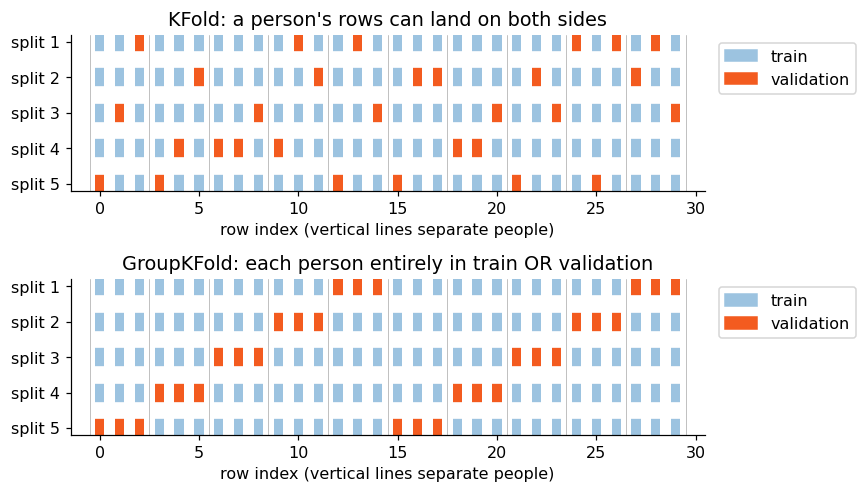

In [15]:
toy_X = np.zeros((30, 1)); toy_y = np.tile([0, 1], 15)
toy_groups = np.repeat(np.arange(10), 3)                 # 10 "people", 3 rows each
fig, axes = plt.subplots(2, 1, figsize=(8, 4.6))
plot_cv_indices(KFold(5, shuffle=True, random_state=0), toy_X, toy_y, axes[0], "KFold: a person's rows can land on both sides")
plot_cv_indices(GroupKFold(5), toy_X, toy_y, axes[1], "GroupKFold: each person entirely in train OR validation", groups=toy_groups)
for ax in axes:
    for b in range(0, 31, 3):
        ax.axvline(b - 0.5, color="black", lw=0.4, alpha=0.4)
    ax.set_xlabel("row index (vertical lines separate people)")
plt.tight_layout(); plt.show()

*COMPAS:* `drop_duplicate_rows()` removes repeated `id`s before the split, so each person appears once — there are no groups to protect, and grouping by `id` would be plain k-fold. You'd pass `groups=` to `cross_validate` if they existed:

```python
from sklearn.model_selection import StratifiedGroupKFold
cross_validate(pipeline, X, y, cv=StratifiedGroupKFold(5, shuffle=True, random_state=42), groups=df["person_id"])
```

A group split can also answer a *different* question on purpose: "how well does the model do for a court / hospital / region it has never seen?" That number is usually lower, and it's the right one to quote if that's how the model will be used.

**Time.** If rows happen over time and the model will predict the future from the past, a shuffled split lets it train on next year and "predict" last year. `TimeSeriesSplit` always validates on the block right after its training data:

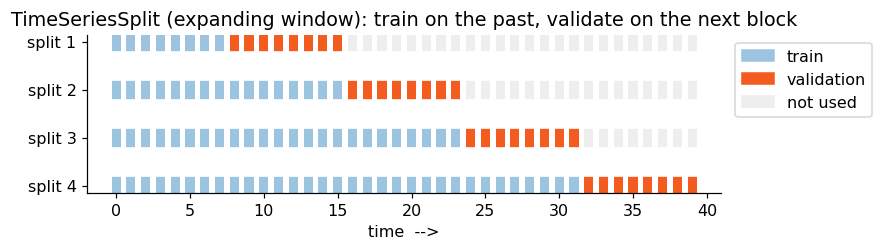

In [16]:
fig, ax = plt.subplots(figsize=(8, 2.4))
plot_cv_indices(TimeSeriesSplit(n_splits=4), np.arange(40).reshape(-1, 1), None, ax,
                "TimeSeriesSplit (expanding window): train on the past, validate on the next block")
ax.set_xlabel("time  -->")
plt.tight_layout(); plt.show()

*COMPAS:* our version has no reliable date column, so we don't use it. *Your project:* if your dataset has dates (e.g. fire ignitions over several years), ask whether a random split lets the model peek at the future. If so: sort by time, use `TimeSeriesSplit` (`gap=` can leave a buffer between train and validation), and make the locked test set the **most recent period**, not a random 20%.

<a class="anchor" id="reliability"></a>
### 3.4 · Which design is most reliable?

A design's job is to estimate how the pipeline does on new data. A good design gives nearly the **same estimate whatever its random seed** — otherwise the number we report depends on luck. We can measure that without touching the test set: run each design 20 times with different seeds and look at how much its estimate moves, and what it costs.

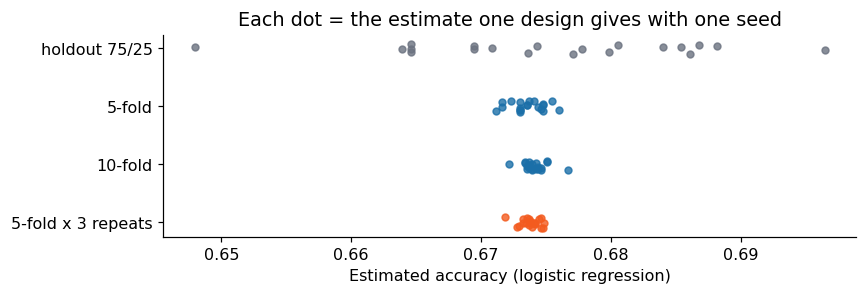

,fits,mean estimate,spread of the estimate (std over 20 seeds),seconds per run
design,,,,
holdout 75/25,1,0.6753,0.0113,0.0511
5-fold,5,0.6736,0.0013,0.1887
10-fold,10,0.6741,0.0009,0.3681
5-fold x 3 repeats,15,0.6738,0.0007,0.5153


In [17]:
designs = {
    "holdout 75/25": lambda s: [next(StratifiedKFold(4, shuffle=True, random_state=s).split(X_dev, y_dev))],
    "5-fold": lambda s: StratifiedKFold(5, shuffle=True, random_state=s),
    "10-fold": lambda s: StratifiedKFold(10, shuffle=True, random_state=s),
    "5-fold x 3 repeats": lambda s: RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=s),
}
lr_pipe = make_pipeline(LR)
rows, estimates = [], {}
for name, make_splitter in designs.items():
    start = time.perf_counter()
    est = [cross_val_score(lr_pipe, X_dev, y_dev, cv=make_splitter(s)).mean() for s in range(20)]
    seconds = (time.perf_counter() - start) / 20
    fits = len(list(make_splitter(0))) if isinstance(make_splitter(0), list) else make_splitter(0).get_n_splits()
    estimates[name] = est
    rows.append({"design": name, "fits": fits, "mean estimate": np.mean(est),
                 "spread of the estimate (std over 20 seeds)": np.std(est, ddof=1), "seconds per run": seconds})

fig, ax = plt.subplots(figsize=(8, 2.8))
for i, (name, est) in enumerate(estimates.items()):
    ax.scatter(est, np.full(20, i) + rng.uniform(-0.1, 0.1, 20), color=[GRAY, BLUE, BLUE, ORANGE][i], alpha=0.8, s=20)
ax.set_yticks(range(len(estimates)), list(estimates)); ax.invert_yaxis()
ax.set_xlabel("Estimated accuracy (logistic regression)"); ax.set_title("Each dot = the estimate one design gives with one seed")
plt.tight_layout(); plt.show()
pd.DataFrame(rows).set_index("design").round(4)

Every design is aiming at the same number; they differ in how **reliably** they hit it. The holdout estimate moves the most from seed to seed; k-fold moves much less; repeating k-fold shrinks it further - at proportionally more fits. For the pipeline, **stratified 5-fold** is the default: a small fraction of the holdout's instability, at a cost we pay every run. When two candidates end up close (Section 5), repeat.

## <font color='#f35b1f'>4. The Leakage Trap: Preprocessing Belongs Inside the Folds</font> <a class="anchor" id="leakage"></a>
[Back to TOC](#toc)

CV is only honest if each validation fold is truly unseen — **including by the preprocessing**. A very common mistake:

```python
X_ready = preprocessor.fit_transform(X_dev, y_dev)   # fit on ALL rows...
cross_val_score(model, X_ready, y_dev, cv=cv)         # ...then cross-validate the model alone        ✗
```

Imputation medians, scaler statistics and - worst of all - target-encoding means were computed with the validation rows included. The correct version cross-validates the pipeline, so everything is re-learned inside each fold:

```python
cross_val_score(make_pipeline(model), X_dev, y_dev, cv=cv)                                          ✓
```

**The rule, for every step that learns from data** — imputer, scaler, encoder, feature selection, outlier removal , resampling such as SMOTE: *it goes inside the pipeline, and the pipeline goes inside CV.* Stateless steps (fixing spellings, impossible values → NaN, dropping duplicates) can run once on everything, which is why `clean_dataset()` stays outside.

## <font color='#f35b1f'>5. Adding Cross-Validation to Your Pipeline</font> <a class="anchor" id="pipeline"></a>
[Back to TOC](#toc)

Everything above used the pipeline's preprocessing. What the pipeline still lacks is the evaluation around it: **`src/evaluate.py`** is rewritten this week. `cross_validate_pipeline()` you've been using since Section 3.2 (it now also returns the out-of-fold predictions, 5.2); the rest turn the results into the report `main.py` prints and saves. No new source files.

### 5.1 · `src/evaluate.py` 

- `cv_report()` and `oof_classification_report()` — the fold table and the classification report as text;
- `fairness_report()` — same audit as before, now on out-of-fold predictions instead of a test split.

In [18]:
# ---- src/evaluate.py -- identical to the pipeline ----
def cv_report(fold_scores: pd.DataFrame, scoring: str = "accuracy") -> str:
    """Per-fold table + mean +/- std, as text (printed, and saved to results/)."""
    lines = [
        f"Cross-validation ({len(fold_scores)} stratified folds, metric: {scoring})",
        "",
        fold_scores.to_string(index=False, float_format=lambda v: f"{v:.3f}"),
        "",
    ]
    for col in ["train", "validation", "gap"]:
        sign = "+" if col == "gap" else ""
        lines.append(f"{col.capitalize():<11s} mean = {fold_scores[col].mean():{sign}.3f}   "
                     f"std = {fold_scores[col].std(ddof=1):.3f}")
    text = "\n".join(lines)
    print(text)
    return text


def oof_classification_report(y_true, y_pred) -> str:
    """Classification report on the out-of-fold predictions."""
    text = "Classification report (out-of-fold predictions, development set):\n" + \
        classification_report(y_true, y_pred, zero_division=0)
    print(text)
    return text


def fairness_report(y_true, y_pred, extras: pd.DataFrame, sensitive_attr: str = "race") -> str:
    """
    Deliberately simple fairness check -- not a substitute for a real audit, just enough
    to show that "accurate" and "fair" are not the same thing.

    For each race group, the false positive rate (share of people who did NOT reoffend
    but were predicted to) for:
        - our own model (out-of-fold predictions on the development set)
        - COMPAS's own risk score (score_text != "Low" counts as a "high risk"
          prediction), on the same rows, for comparison
    """
    df = extras.copy()
    df["y_true"] = pd.Series(y_true).values
    df["y_pred_model"] = y_pred
    df["y_pred_compas"] = (df["score_text"] != "Low").astype(int)

    lines = [
        "False positive rate by race (development set, out-of-fold)",
        "(share of people who did NOT reoffend, but were predicted to)",
        "",
    ]

    for label, col in [("Our model", "y_pred_model"), ("COMPAS's own score", "y_pred_compas")]:
        lines.append(f"  {label}:")
        for group, g in df.groupby(sensitive_attr):
            negatives = g[g["y_true"] == 0]
            if len(negatives) == 0:
                continue
            fpr = (negatives[col] == 1).mean()
            lines.append(f"    {group:<20s} FPR = {fpr:.2f}  (n={len(negatives)})")
        lines.append("")

    text = "\n".join(lines)
    print(text)
    return text

Run on the model currently in `config.yaml`, exactly as `main.py` does:

In [19]:
pipeline = make_pipeline(config["model"])
scoring = cv_config.get("scoring", "accuracy")
fold_scores, y_oof = cross_validate_pipeline(
    pipeline, X_dev, y_dev, cv, scoring, n_jobs=cv_config.get("n_jobs", 1)
)
_ = cv_report(fold_scores, scoring)

Cross-validation (5 stratified folds, metric: accuracy)

 fold  train  validation    gap
    1  0.676       0.680 -0.004
    2  0.680       0.654  0.026
    3  0.674       0.675 -0.001
    4  0.672       0.688 -0.016
    5  0.674       0.665  0.010

Train       mean = 0.675   std = 0.003
Validation  mean = 0.672   std = 0.013
Gap         mean = +0.003   std = 0.016


### 5.2 · Out-of-fold predictions

The classification report and the fairness audit need *predictions*, not just a score. `cross_validate_pipeline()` already returned them (`y_oof`): each development row gets one from the fold model that **didn't** train on it - ~5,800 unseen-row predictions instead of ~1,400 from one test split, and the test set stays locked:

In [20]:
print(f"{len(y_oof)} out-of-fold predictions, accuracy {accuracy_score(y_dev, y_oof):.3f}")

5771 out-of-fold predictions, accuracy 0.672


### 5.3 · Evaluation ends in a model

CV fits 5 models and **throws them away**: it estimates how good the *recipe* is. The model you'd actually use is the same pipeline refit on **all** development rows:

In [21]:
final_model = make_pipeline(config["model"]).fit(X_dev, y_dev)
print(f"Final model: {config['model']['type']} refit on all {len(X_dev)} development rows.")

Final model: logistic_regression refit on all 5771 development rows.


### 5.4 · The other changes

| File | Change |
|---|---|
| `src/preprocessing.py` | `split_train_test()` → **`split_dev_test()`** (Section 2.1); target encoder → sklearn's `TargetEncoder(target_type="binary", random_state=...)`; the `"nan"` bug fix and row-preserving `clean_dataset()` + training-only `drop_duplicate_rows()` (`02_preprocessing.ipynb`, 3.2–3.3) |
| `src/model.py` | two new entries in `_MODELS`: `"dummy": DummyClassifier` and `"random_forest": RandomForestClassifier` |
| `src/data_diagnostics.py` | **removed** — its one cleaning function, `flag_invalid_values()`, moved into `src/preprocessing.py`; the EDA-only checks stay in the EDA notebooks |
| `src/results.py` | run header records the CV settings and the locked test set |
| `config.yaml` | `split` → **`test_set`** (never change it again); new **`cv`** section; `preprocessing.random_state: 42`, `scaler: robust` |


### 5.5 · Before vs after CV - the table for this week's README

The "holdout" columns are what the pipeline did up to week 3; the "CV" columns are what it does now. Your numbers will differ slightly: your W3 `results/` files hold your holdout accuracy, and `python main.py` now prints your CV numbers.

In [22]:
rows = []
for name in MODELS:
    t = cv_table(name)
    rows.append({"model": name,
                 "holdout (1 split)": holdout[name].iloc[0],
                 "holdout range, 30 seeds": f"{holdout[name].min():.3f} - {holdout[name].max():.3f}",
                 "CV accuracy (mean ± std)": f"{t['validation'].mean():.3f} ± {t['validation'].std(ddof=1):.3f}",
                 "CV train - val gap": round(t["gap"].mean(), 3)})
pd.DataFrame(rows).set_index("model").round(3)

,holdout (1 split),"holdout range, 30 seeds",CV accuracy (mean ± std),CV train - val gap
model,,,,
Dummy (majority),0.550,0.550 - 0.550,0.549 ± 0.000,-0.000
Logistic regression,0.672,0.658 - 0.697,0.672 ± 0.013,0.003
Decision tree,0.602,0.558 - 0.624,0.611 ± 0.015,0.084
Random forest,0.655,0.623 - 0.674,0.652 ± 0.017,0.080


# <font color='#f35b1f'>Key Takeaways</font> <a class="anchor" id="takeaways"></a>
[Back to TOC](#toc)

## Update your README (due Saturday 23:59)

Add this week's row to "Pipeline progress", and a new section:

```markdown
## Model evaluation
How the pipeline evaluates models, and why (locked test set + stratified 5-fold CV).

| Model | Holdout accuracy (W3) | CV accuracy (mean ± std) | CV train–val gap |
|---|---|---|---|
| Dummy | ... | ... | ... |
| Logistic regression | ... | ... | ... |
| Decision tree | ... | ... | ... |
| Random forest | — | ... | ... |

3–5 sentences: which number would you trust, and why? Does your week 2/3 "best model"
conclusion still hold under cross-validation?
```

(Switch `model.type` in `config.yaml` between `dummy`, `logistic_regression`, `decision_tree` and `random_forest` — there's a commented example for the forest — and run `python main.py` for each row.)

## Challenge - once CV runs in your pipeline

You now have a pipeline that evaluates honestly. Use it to test a change the way you'll test every change from now on: **try a different way of handling missing values, and let cross-validation decide.**

1. **Add an option.** Give `build_preprocessor()` a second numeric imputation strategy, chosen in `config.yaml` — e.g. `imputation.numeric_strategy: "knn"`, using `sklearn.impute.KNNImputer(n_neighbors=...)` (add `n_neighbors` to the config too). It fills a gap from the most similar rows instead of the column median. Note: KNN measures distances, so the scale of each column matters — think about whether the scaler should come before or after the imputer. Other ideas: `SimpleImputer(strategy="mean")`, or `add_indicator=True` for every column.
2. **Compare it the new way:** your pipeline's 5-fold CV, both recipes on the **same folds** (same `cv.random_state`), and the corrected paired comparison from Section 5.
4. **Write it up in your README:** a small table (holdout per seed vs CV mean ± std, for both recipes), and 3–5 sentences — did the single split and CV agree? Or did it change model scores? Which recipe stays in your `config.yaml`, and why?